In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn import metrics
from sklearn.metrics import roc_curve, auc, RocCurveDisplay



In [2]:
df_test = pd.read_csv('alzheimers_disease_data.csv')

In [3]:
cols = df_test.columns.tolist()
target_col ='Diagnosis'
cols.remove(target_col)
cols.append(target_col)
df_reordered = df_test[cols]
df_test = df_reordered


In [4]:
df_test = df_test.drop(['PatientID','DoctorInCharge'], axis=1, errors='ignore')



In [5]:
df_test.head()
df_test.tail()
df_test.info()
df_test.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        2149 non-null   int64  
 1   Gender                     2149 non-null   int64  
 2   Ethnicity                  2149 non-null   int64  
 3   EducationLevel             2149 non-null   int64  
 4   BMI                        2149 non-null   float64
 5   Smoking                    2149 non-null   int64  
 6   AlcoholConsumption         2149 non-null   float64
 7   PhysicalActivity           2149 non-null   float64
 8   DietQuality                2149 non-null   float64
 9   SleepQuality               2149 non-null   float64
 10  FamilyHistoryAlzheimers    2149 non-null   int64  
 11  CardiovascularDisease      2149 non-null   int64  
 12  Diabetes                   2149 non-null   int64  
 13  Depression                 2149 non-null   int64

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,...,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000
mean,74.908795,0.506282,0.697534,1.286645,27.655697,0.288506,10.039442,4.920202,4.993138,7.051081,...,5.080055,0.208004,0.156817,4.982958,0.205212,0.158213,0.150768,0.158678,0.301536,0.353653
std,8.990221,0.500077,0.996128,0.904527,7.217438,0.453173,5.757910,2.857191,2.909055,1.763573,...,2.892743,0.405974,0.363713,2.949775,0.403950,0.365026,0.357906,0.365461,0.459032,0.478214
min,60.000000,0.000000,0.000000,0.000000,15.008851,0.000000,0.002003,0.003616,0.009385,4.002629,...,0.000460,0.000000,0.000000,0.001288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,67.000000,0.000000,0.000000,1.000000,21.611408,0.000000,5.139810,2.570626,2.458455,5.482997,...,2.566281,0.000000,0.000000,2.342836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,75.000000,1.000000,0.000000,1.000000,27.823924,0.000000,9.934412,4.766424,5.076087,7.115646,...,5.094439,0.000000,0.000000,5.038973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,83.000000,1.000000,1.000000,2.000000,33.869778,1.000000,15.157931,7.427899,7.558625,8.562521,...,7.546981,0.000000,0.000000,7.581490,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,90.000000,1.000000,3.000000,3.000000,39.992767,1.000000,19.989293,9.987429,9.998346,9.999840,...,9.996467,1.000000,1.000000,9.999747,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
train, valid, test = np.split(df_test.sample(frac=1), [int(0.6*len(df_test)), int(0.8*len(df_test))])

C:\Users\aveli\anaconda3\envs\cop501CW\lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [7]:
def scale_dataset(dataframe, oversample = False):
    X = dataframe.iloc[:, :-1].values
    y = dataframe.iloc[:, -1].values
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    
    if oversample:
        ros = RandomOverSampler()
        X, y = ros.fit_resample(X, y)
       
        
    
    data = np.hstack((X, np.reshape(y, (-1, 1))))
    return data , X, y



In [8]:
train, X_train, y_train = scale_dataset(train, oversample=True)
valid, X_valid, y_valid = scale_dataset(valid, oversample=False)
test, X_test, y_test = scale_dataset(test, oversample=False)

In [9]:
sum(y_train ==1)


np.int64(831)

In [10]:
sum(y_train ==0)

np.int64(831)

KNN

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

In [12]:
knnmodel = KNeighborsClassifier(n_neighbors =3)
knnmodel.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [13]:
y_predict = knnmodel.predict(X_test)
print(classification_report(y_test , y_predict))
print(confusion_matrix(y_test, y_predict))


              precision    recall  f1-score   support

           0       0.78      0.78      0.78       273
           1       0.62      0.62      0.62       157

    accuracy                           0.72       430
   macro avg       0.70      0.70      0.70       430
weighted avg       0.72      0.72      0.72       430

[[212  61]
 [ 59  98]]


In [14]:
y_val_probs = knnmodel.predict_proba(X_valid)[:, 1]
y_test_probs = knnmodel.predict_proba(X_test)[:, 1]

In [15]:
fpr_val, tpr_val, _ = roc_curve(y_valid, y_val_probs)
auc_val = auc(fpr_val, tpr_val)

In [16]:
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_probs)
auc_test = auc(fpr_test, tpr_test)

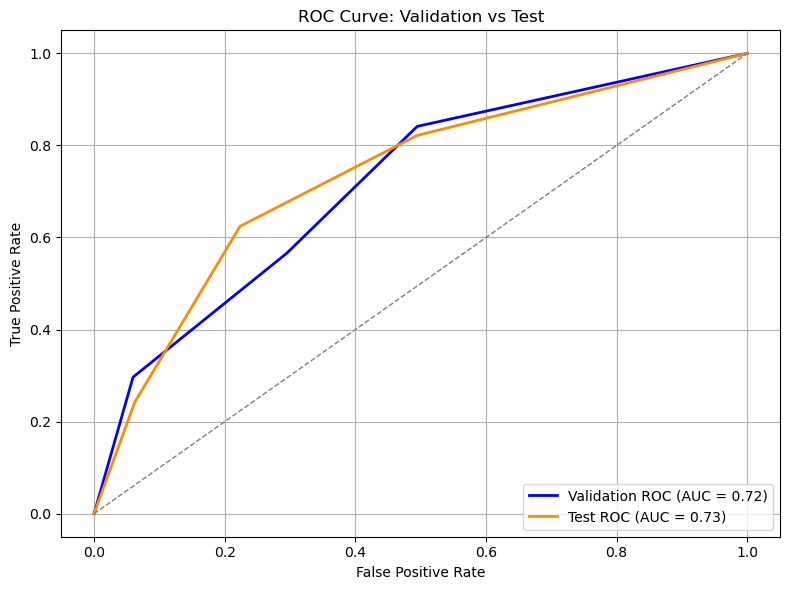

In [17]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_val, tpr_val, color='blue', lw=2, label=f'Validation ROC (AUC = {auc_val:.2f})')
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2, label=f'Test ROC (AUC = {auc_test:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Validation vs Test')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

Navie Baise

In [18]:
from sklearn.naive_bayes import GaussianNB

In [19]:
nb_model = GaussianNB()
nb_model = nb_model.fit(X_train, y_train)

In [20]:
nb_model = GaussianNB()
nb_model = nb_model.fit(X_train, y_train)

In [21]:
y_pred = nb_model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))



              precision    recall  f1-score   support

           0       0.87      0.79      0.83       273
           1       0.69      0.79      0.73       157

    accuracy                           0.79       430
   macro avg       0.78      0.79      0.78       430
weighted avg       0.80      0.79      0.79       430

[[216  57]
 [ 33 124]]


In [22]:
y_val_probs = nb_model.predict_proba(X_valid)[:, 1]
y_test_probs = nb_model.predict_proba(X_test)[:, 1]

In [23]:
fpr_val, tpr_val, _ = roc_curve(y_valid, y_val_probs)
auc_val = auc(fpr_val, tpr_val)

In [24]:
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_probs)
auc_test = auc(fpr_test, tpr_test)

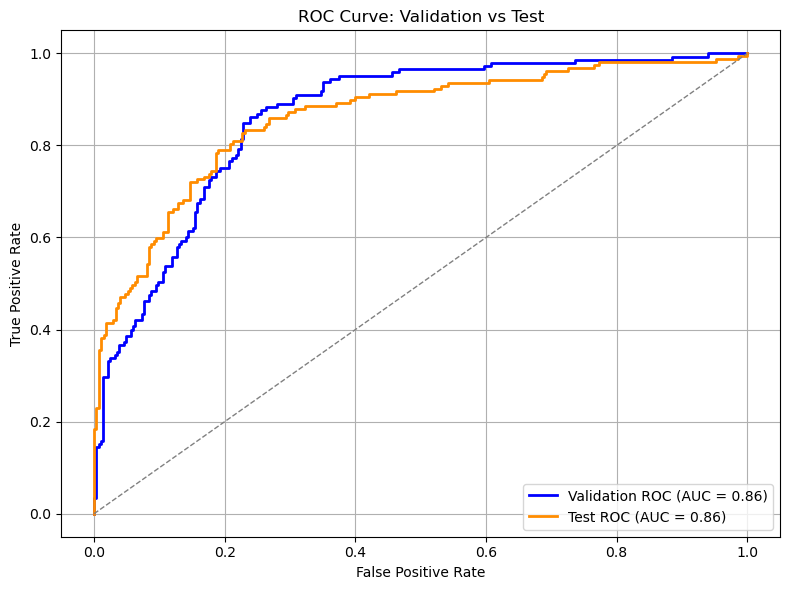

In [25]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_val, tpr_val, color='blue', lw=2, label=f'Validation ROC (AUC = {auc_val:.2f})')
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2, label=f'Test ROC (AUC = {auc_test:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Validation vs Test')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

Logistic Regression 

In [26]:
from sklearn.linear_model import LogisticRegression

In [27]:
lg_model = LogisticRegression()
lg_model = nb_model.fit(X_train, y_train)

In [28]:
y_pred = lg_model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.87      0.79      0.83       273
           1       0.69      0.79      0.73       157

    accuracy                           0.79       430
   macro avg       0.78      0.79      0.78       430
weighted avg       0.80      0.79      0.79       430

[[216  57]
 [ 33 124]]


In [29]:
y_val_probs = lg_model.predict_proba(X_valid)[:, 1]
y_test_probs = lg_model.predict_proba(X_test)[:, 1]

In [30]:
fpr_val, tpr_val, _ = roc_curve(y_valid, y_val_probs)
auc_val = auc(fpr_val, tpr_val)

In [31]:
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_probs)
auc_test = auc(fpr_test, tpr_test)

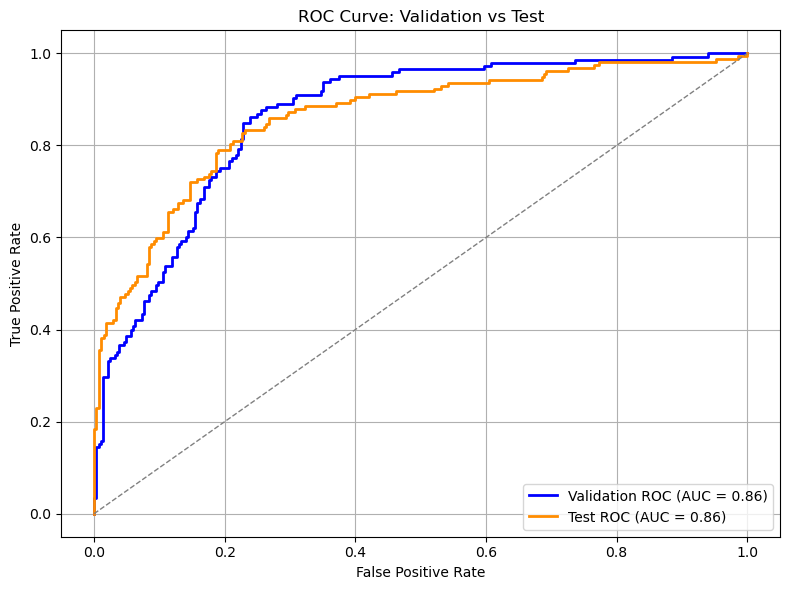

In [32]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_val, tpr_val, color='blue', lw=2, label=f'Validation ROC (AUC = {auc_val:.2f})')
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2, label=f'Test ROC (AUC = {auc_test:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Validation vs Test')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

SVM

In [33]:
from sklearn.svm import SVC

In [34]:
svm_model = SVC(probability=True)
svm_model = svm_model.fit(X_train, y_train)

In [35]:
y_pred = svm_model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.87      0.84      0.86       273
           1       0.74      0.78      0.76       157

    accuracy                           0.82       430
   macro avg       0.80      0.81      0.81       430
weighted avg       0.82      0.82      0.82       430

[[230  43]
 [ 35 122]]


In [36]:
y_val_probs = svm_model.predict_proba(X_valid)[:, 1]
y_test_probs = svm_model.predict_proba(X_test)[:, 1]

In [37]:
fpr_val, tpr_val, _ = roc_curve(y_valid, y_val_probs)
auc_val = auc(fpr_val, tpr_val)

In [38]:
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_probs)
auc_test = auc(fpr_test, tpr_test)

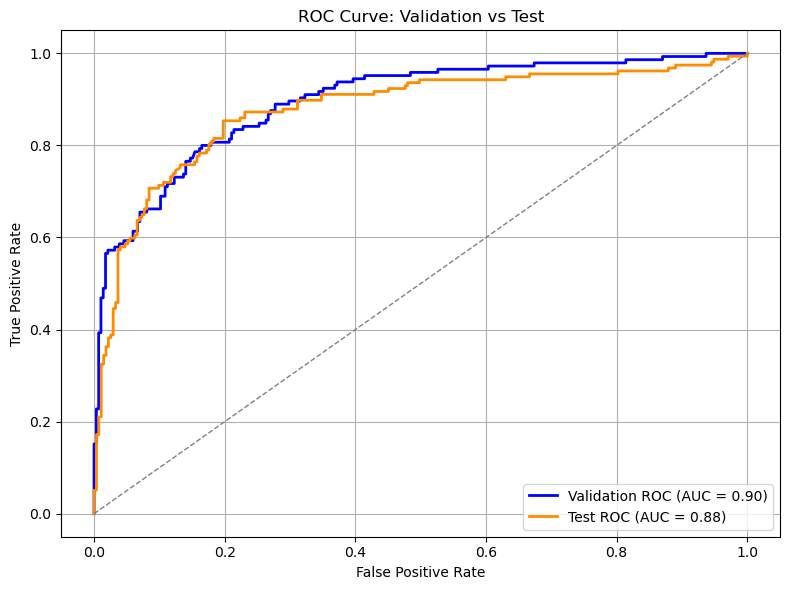

In [39]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_val, tpr_val, color='blue', lw=2, label=f'Validation ROC (AUC = {auc_val:.2f})')
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2, label=f'Test ROC (AUC = {auc_test:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Validation vs Test')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

Decission Tree

In [40]:
from sklearn import tree

In [41]:
tree_model = tree.DecisionTreeClassifier()
tree_model = tree_model.fit(X_train , y_train)

In [42]:
y_pred = tree_model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.90      0.91      0.90       273
           1       0.84      0.82      0.83       157

    accuracy                           0.88       430
   macro avg       0.87      0.86      0.87       430
weighted avg       0.88      0.88      0.88       430

[[249  24]
 [ 29 128]]


In [43]:
y_val_probs = tree_model.predict_proba(X_valid)[:, 1]
y_test_probs = tree_model.predict_proba(X_test)[:, 1]

In [44]:
fpr_val, tpr_val, _ = roc_curve(y_valid, y_val_probs)
auc_val = auc(fpr_val, tpr_val)

In [45]:
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_probs)
auc_test = auc(fpr_test, tpr_test)

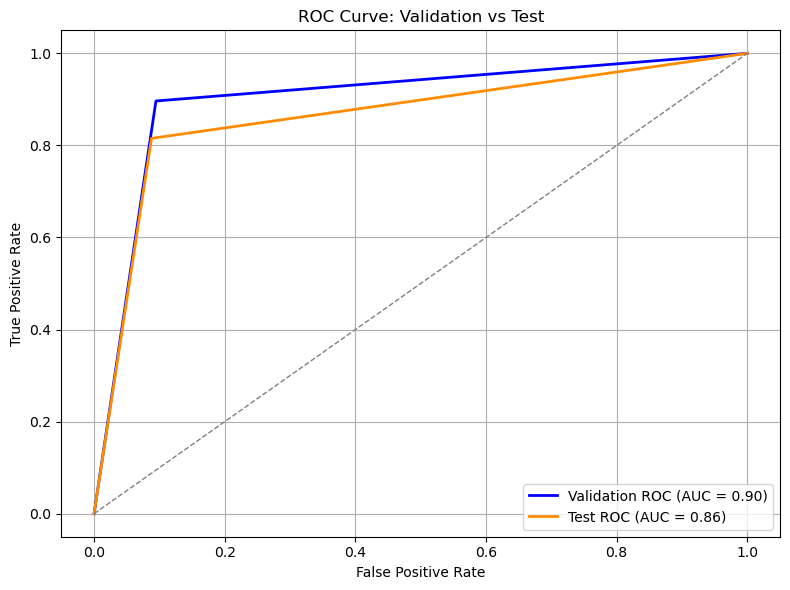

In [46]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_val, tpr_val, color='blue', lw=2, label=f'Validation ROC (AUC = {auc_val:.2f})')
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2, label=f'Test ROC (AUC = {auc_test:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Validation vs Test')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

Random Forest

In [47]:
from sklearn.ensemble import RandomForestClassifier

In [48]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

RandomForestClassifier()

In [49]:
y_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.90      0.97      0.93       273
           1       0.93      0.82      0.87       157

    accuracy                           0.91       430
   macro avg       0.92      0.89      0.90       430
weighted avg       0.92      0.91      0.91       430

[[264   9]
 [ 28 129]]


In [50]:
y_val_probs = rf_model.predict_proba(X_valid)[:, 1]
y_test_probs = rf_model.predict_proba(X_test)[:, 1]

In [51]:
fpr_val, tpr_val, _ = roc_curve(y_valid, y_val_probs)
auc_val = auc(fpr_val, tpr_val)

In [52]:
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_probs)
auc_test = auc(fpr_test, tpr_test)

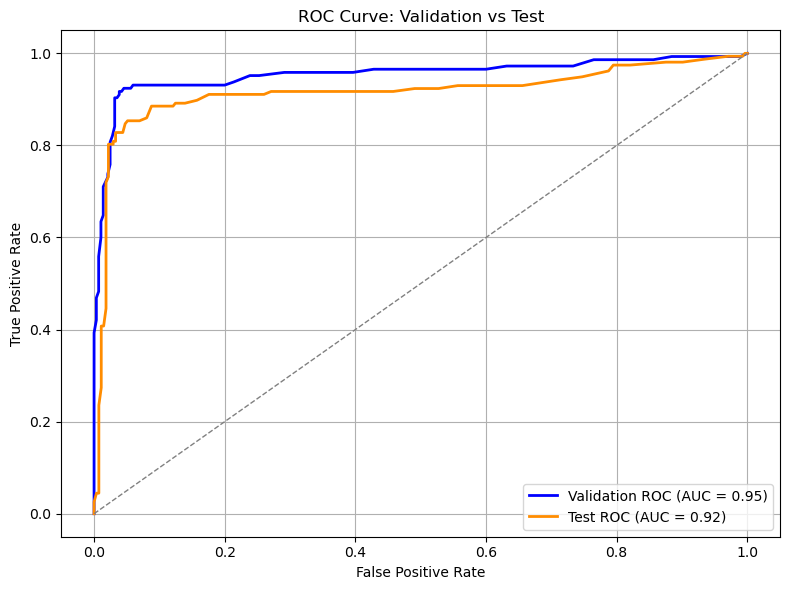

In [53]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_val, tpr_val, color='blue', lw=2, label=f'Validation ROC (AUC = {auc_val:.2f})')
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2, label=f'Test ROC (AUC = {auc_test:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Validation vs Test')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

Gradient Boosting

In [54]:
from sklearn.ensemble import GradientBoostingClassifier


In [55]:
gb_model = GradientBoostingClassifier()
gb_model.fit(X_train, y_train)

GradientBoostingClassifier()

In [56]:
y_pred = gb_model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.92      0.94      0.93       273
           1       0.89      0.87      0.88       157

    accuracy                           0.91       430
   macro avg       0.91      0.90      0.90       430
weighted avg       0.91      0.91      0.91       430

[[256  17]
 [ 21 136]]


In [57]:
y_val_probs = gb_model.predict_proba(X_valid)[:, 1]
y_test_probs = gb_model.predict_proba(X_test)[:, 1]

In [58]:
fpr_val, tpr_val, _ = roc_curve(y_valid, y_val_probs)
auc_val = auc(fpr_val, tpr_val)

In [59]:
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_probs)
auc_test = auc(fpr_test, tpr_test)

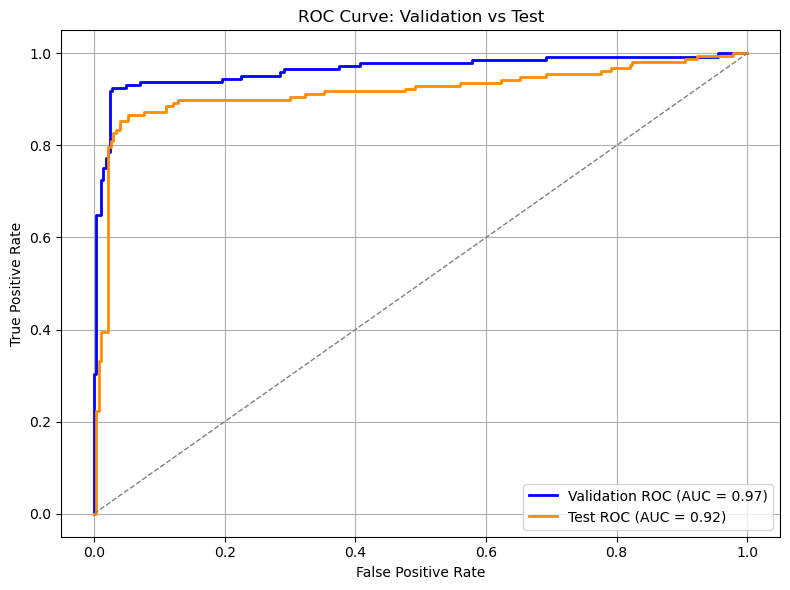

In [60]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_val, tpr_val, color='blue', lw=2, label=f'Validation ROC (AUC = {auc_val:.2f})')
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2, label=f'Test ROC (AUC = {auc_test:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Validation vs Test')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

AdaBoost 

In [61]:
from sklearn.ensemble import AdaBoostClassifier


In [62]:
ad_model = AdaBoostClassifier()
ad_model.fit(X_train, y_train)

AdaBoostClassifier()

In [63]:
y_pred = ad_model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.93      0.90      0.91       273
           1       0.83      0.89      0.86       157

    accuracy                           0.89       430
   macro avg       0.88      0.89      0.89       430
weighted avg       0.90      0.89      0.89       430

[[245  28]
 [ 18 139]]


In [64]:
y_val_probs = ad_model.predict_proba(X_valid)[:, 1]
y_test_probs = ad_model.predict_proba(X_test)[:, 1]

In [65]:
fpr_val, tpr_val, _ = roc_curve(y_valid, y_val_probs)
auc_val = auc(fpr_val, tpr_val)

In [66]:
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_probs)
auc_test = auc(fpr_test, tpr_test)

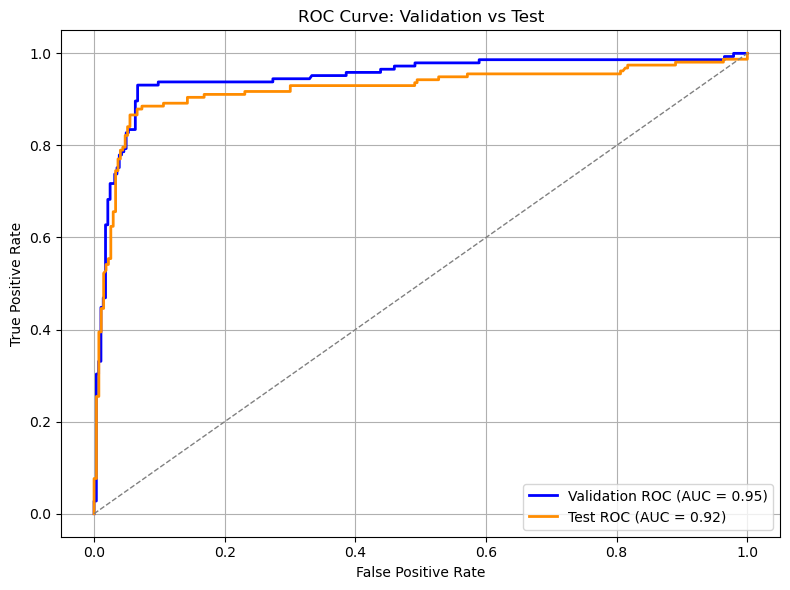

In [67]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_val, tpr_val, color='blue', lw=2, label=f'Validation ROC (AUC = {auc_val:.2f})')
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2, label=f'Test ROC (AUC = {auc_test:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Validation vs Test')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

XBoost


In [68]:
from xgboost import XGBClassifier

In [69]:
xboost_model = XGBClassifier()
xboost_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [70]:
y_pred = xboost_model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.79      0.98      0.88       273
           1       0.95      0.55      0.70       157

    accuracy                           0.83       430
   macro avg       0.87      0.77      0.79       430
weighted avg       0.85      0.83      0.81       430

[[268   5]
 [ 70  87]]


SHAP Analysis

In [90]:
import shap

In [91]:
feature_names = df_test.drop('Diagnosis', axis=1).columns

X_train = pd.DataFrame(X_train, columns=feature_names)
X_test = pd.DataFrame(X_test, columns=feature_names)

In [92]:
top_features = shap.Explainer(gb_model, X_train)
shap_values = top_features(X_train)

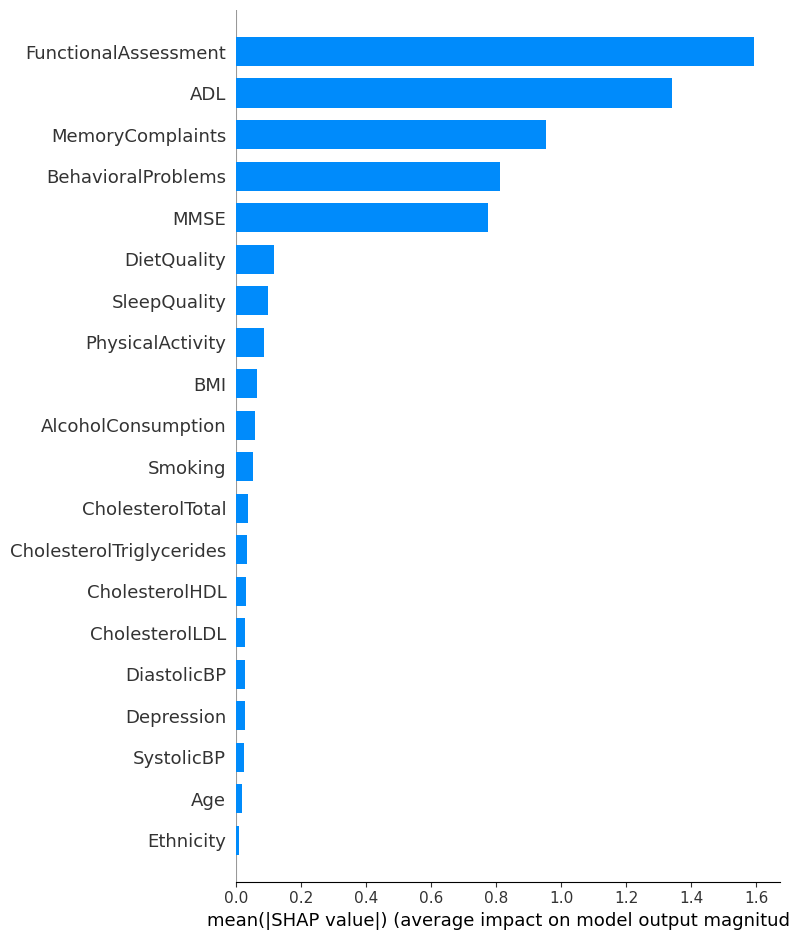

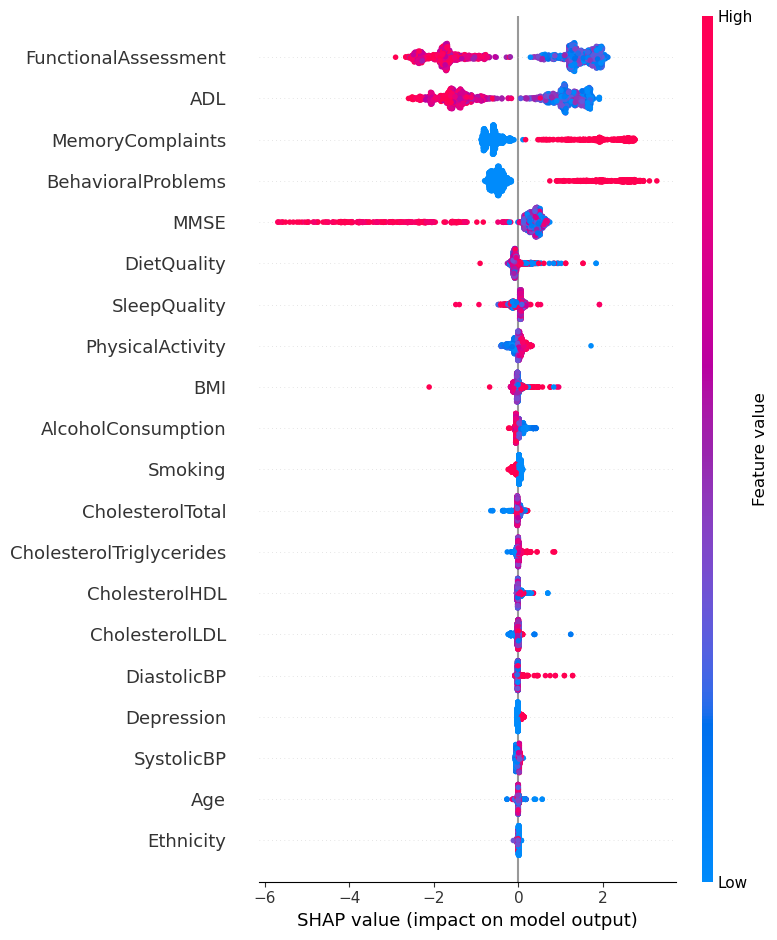

In [93]:
shap.summary_plot(shap_values, X_train, plot_type="bar")
shap.summary_plot(shap_values, X_train)

In [111]:
from sklearn.neural_network import MLPClassifier
lf = MLPClassifier(hidden_layer_sizes=(64, 32), 
                    activation='relu', 
                    solver='adam',
                    max_iter=300, 
                    random_state=1)
lf.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=10000, random_state=1)

In [112]:
y_pred = lf.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.83      0.85      0.84       273
           1       0.72      0.69      0.71       157

    accuracy                           0.79       430
   macro avg       0.77      0.77      0.77       430
weighted avg       0.79      0.79      0.79       430

[[231  42]
 [ 48 109]]
